# 2D Radiation Emitter

This notebook demonstrates how to create a radiation emitter from 2D profiles stored in an IMAS [radiation IDS](https://imas-data-dictionary.readthedocs.io/en/latest/generated/ids/radiation.html).

The example test data was calculated by SOLPS-ITER for an ITER scenario.

In [1]:
import numpy as np
import ultraplot as uplt
from raysect.optical import World

from cherab.imas.datasets import iter_solps
from cherab.imas.emitter import load_radiation_emitter

# Set dark background for plots
uplt.rc.style = "dark_background"

## Retrieve SOLPS-ITER sample data

In [2]:
path = iter_solps()

## Create 3D radiation emitter from IMAS IDS

In [3]:
world = World()
emitter = load_radiation_emitter(
    path,
    parent=world,
    interpolator_cache="disk",
)

14:38:20 INFO     Parsing data dictionary version 4.1.1 @dd_zip.py:89


14:38:21 INFO     Parsing data dictionary version 4.0.0 @dd_zip.py:89


/home/runner/work/imas/imas/src/cherab/imas/emitter/radiation.py:347: RuntimeWarning: The 'get_slice' method is not implemented for the URI '/home/runner/.cache/cherab/imas/iter_scenario_123364_1.nc'. Falling back to 'get' method because the returned IDS contains a single time slice.
  ids = get_ids_time_slice(


## Visualize the emitter in 2D

Sample 2D visualization of the radiation function.

In [4]:
R_MIN, R_MAX = 4.0, 8.5
Z_MIN, Z_MAX = -4.7, 4.8
RES = 0.01  # resolution of grid in [m]
n_r = round((R_MAX - R_MIN) / RES) + 1
n_z = round((Z_MAX - Z_MIN) / RES) + 1
dr, dz = (R_MAX - R_MIN) / (n_r - 1), (Z_MAX - Z_MIN) / (n_z - 1)

# (r, z) coordinates at phi=0
r_pts = np.linspace(R_MIN, R_MAX, n_r, endpoint=True)
z_pts = np.linspace(Z_MIN, Z_MAX, n_z, endpoint=True)

In [5]:
rad = np.zeros((n_r, n_z), dtype=float)
for i, j in np.ndindex(n_r, n_z):
    rad[i, j] = emitter.material.radiation_function(
        r_pts[i],
        0.0,
        z_pts[j],
    )

### Cross-sectional view of the radiation

2D poloidal cross-sections of the radiation function.

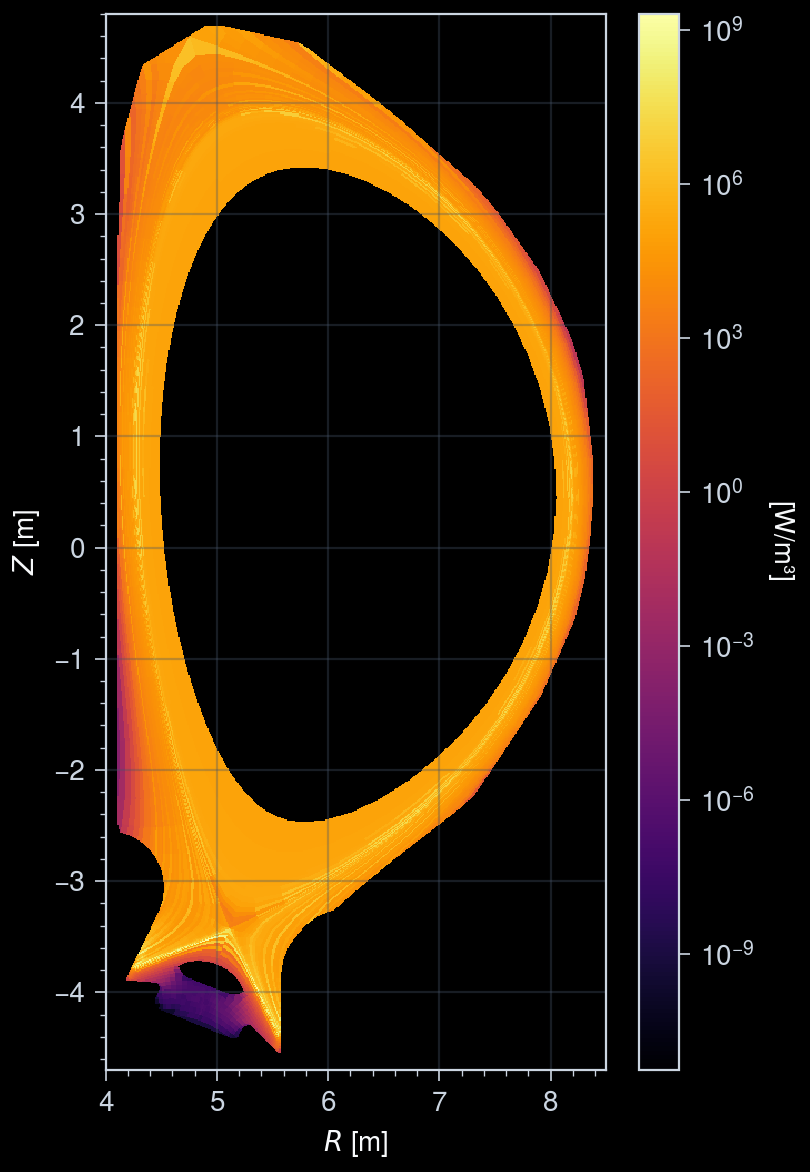

In [6]:
rad[rad <= 0] = np.nan  # set non-positive values to NaN for log scale plotting

fig, ax = uplt.subplots()

im = ax.pcolormesh(
    r_pts,
    z_pts,
    rad.T,
    shading="auto",
    cmap="inferno",
    discrete=False,
    norm="log",
)
ax.colorbar(
    im,
    loc="r",
    label="[W/m³]",
    tickminor=True,
    formatter="log",
)
ax.format(
    aspect="equal",
    titleborder=False,
    xlim=(R_MIN, R_MAX),
    ylim=(Z_MIN, Z_MAX),
    xlabel="$R$ [m]",
    ylabel="$Z$ [m]",
    grid=True,
    xlocator=1,
    ylocator=1,
    tickminor=True,
)